Karttanäkymät sekä vuositason analyysit - Map views and year-level analyses

Df, time_df ja geo_df määriteltyinä all_dataframes.py tiedostossa. DataFramet luotu SparkSession rakenteella. 

Df, time_df and geo_df are defined in the all_dataframes.py file and all DataFrames are created using the SparkSession structure


In [26]:
from pyspark.sql.functions import col, year, month
from all_dataframes import load_base_df, create_time_df, create_geo_df
import matplotlib.pyplot as plt
import pandas as pd


# Koko datasetin ja haluttujen dataframejen lataus
df = load_base_df("C:/Users/serko/US_ACCIDENTS/US_Accidents_March23.csv")

time_df = create_time_df(df)

geo_df = create_geo_df(df)

Base DataFrame loaded.

time_df created.

geo_df created.


Top10 kaupungeista, joissa eniten onnettomuuksia (top 10), onnettomuuksien kokonaismäärä, vakavien onnettomuuksien määrä (severity 3,4) sekä vakavien onnettomuuksien prosenttiosuus. 
Visualisointi ja karttanäkymä. 

Top 10 cities with the highest number of accidents (top 10), the total number of accidents, the number of severe accidents (severity 3 and 4), and the percentage of severe accidents.
Visualization and map view.

In [27]:
from pyspark.sql.functions import col, count, round

# Top-10 kaupungit koko aineistosta
top10_cities = (
    df.groupBy("City")
      .agg(count("*").alias("accident_count"))
      .orderBy(col("accident_count").desc())
      .limit(10)
)

# Vakavat onnettomuudet (severity 3 ja 4)
df_severe = df.filter(col("Severity").isin(3, 4))

severe_counts = (
    df_severe.groupBy("City")
             .agg(count("*").alias("severe_count"))
)

# Yhdistäminen
city_stats = (
    top10_cities.join(severe_counts, on="City", how="left")
                .fillna(0)
                .withColumn(
                    "severe_percentage",
                    round((col("severe_count") / col("accident_count")) * 100, 2)
                )
                .orderBy(col("accident_count").desc())
)

# taulukko
city_stats_pd = city_stats.toPandas()
display(city_stats_pd)


,City,accident_count,severe_count,severe_percentage
0,Miami,186917,16842,9.01
1,Houston,169609,30521,17.99
2,Los Angeles,156491,35866,22.92
3,Charlotte,138652,7898,5.70
4,Dallas,130939,34223,26.14
5,Orlando,109733,7083,6.45
6,Austin,97359,9024,9.27
7,Raleigh,86079,8518,9.90
8,Nashville,72930,11064,15.17
9,Baton Rouge,71588,6827,9.54


Luodaan karttanäkymä, joka näyttää 10 eniten onnettomuuksia sisältänyttä kaupunkia ja tehdään aggregaatti eli näyttää kartalla vain 10 pistettä. Pisteiden päältä klikatessa näyttää kaupungin nimen ja onnettomuuksien määrän.

Create a map view that displays the 10 cities with the highest number of accidents, using an aggregated representation so that only 10 points appear on the map. When clicking on a point, the map should show the city name and the total number of accidents.


Karttanäkymästä luotiin myös HTML‑versio, jonka voi avata selaimessa. HTML‑tiedosto sisältää interaktiivisen kartan, jossa käyttäjä voi tarkastella kaupunkien sijainteja ja onnettomuusmääriä ilman Python‑ympäristöä.

An HTML version of the map view was also generated. The HTML file can be opened in any web browser and contains an interactive map that allows users to explore city locations and accident counts without requiring a Python environment.


In [28]:
from pyspark.sql.functions import col, avg, first

# haetaan 10 kaupungia, joissa eniten onnettomuuksia
top10_df = (
    df.groupBy("City")
      .count()
      .orderBy(col("count").desc())
      .limit(10)
)

# Liitetään koordinaatit ja lasketaan koordinaattien keskiarvot
top10_agg = (
    df.join(top10_df, on="City", how="inner")
      .groupBy("City")
      .agg(
          avg("Start_Lat").alias("lat"),
          avg("Start_Lng").alias("lng"),
          first("count").alias("count")
      )
      .withColumnRenamed("City", "City")
      .orderBy(col("count").desc())
      .toPandas()
)


In [29]:
import folium
from folium.plugins import MarkerCluster


# Keskitetään kartta USA:n keskelle
m = folium.Map(location=[39.5, -98.35], zoom_start=4)


# karttapisteet
city_color = {row["City"]: "blue" for _, row in top10_agg.iterrows()}

for i, row in top10_agg.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=10,
        color=city_color[row["City"]],
        fill=True,
        fill_opacity=0.8,
        popup=f"City: {row['City']}<br>Accidents: {row['count']}"
    ).add_to(m)



In [30]:
# kartan tallennus

m.save("top10_cities_map.html")
m

In [31]:
# kartan avaus selaimessa

import webbrowser
webbrowser.open("top10_cities_map.html")

True

Toinen versio, joka näyttää top-10 kaupungeista ja vakavista liikenneonnettomuuksista (severity 3 ja 4) taulukko- ja karttanäkymän. Karttapisteissä näkyy kaupungin nimi ja onnettomuuksien määrä.

A second version that presents a table and map view of the top 10 cities with the highest number of severe traffic accidents (severity levels 3 and 4). The map markers display the city name and the number of accidents.


In [32]:
from pyspark.sql.functions import col, avg, count

# Vakavuusluokkien severity 3 ja 4 suodatus

df_severe = df.filter(col("Severity").isin(3, 4))

# Lasketaan top 10 kaupunkia näistä onnettomuuksista
sev_top10_df = (
    df_severe.groupBy("City")
      .agg(count("*").alias("accident_count"))
      .orderBy(col("accident_count").desc())
      .limit(10)
)

# Lasketaan koordinaattien keskiarvot ja liitetään mukaan count
sev_top10_agg = (
    df_severe.join(sev_top10_df, on="City", how="inner")
      .groupBy("City", "accident_count")
      .agg(
          avg("Start_Lat").alias("lat"),
          avg("Start_Lng").alias("lng")
      )
      .orderBy(col("accident_count").desc())
      .toPandas()
)


In [33]:
from IPython.display import display

# Näytetään tulos myös taulukkona
sev_top10_table = sev_top10_agg[["City", "accident_count"]]
display(sev_top10_table)

# Luodaan uusi kartta joka kerta (estää duplikaatit)
m = folium.Map(location=[39.5, -98.35], zoom_start=4)

for _, row in sev_top10_agg.iterrows():

    # Kartalle piste
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=10,
        color="red",
        fill=True,
        fill_color="red",
        fill_opacity=0.7
    ).add_to(m)

    # tekstilabel
    folium.Marker(
        location=[row["lat"], row["lng"]],
        icon=folium.DivIcon(
            html=f"""
                <div style="
                    position: relative;
                    bottom: 20px;      /* nostaa tekstin palluran yläpuolelle */
                    left: 12px;        /* siirtää hieman oikealle */
                    font-size: 12px;
                    font-weight: normal;
                    color: black;
                    white-space: nowrap;  /* pakottaa yhdelle riville */
                    background-color: rgba(255,255,255,0.8);
                    padding: 2px 4px;
                    border-radius: 3px;
                ">
                    {row['City']}: {row['accident_count']}
                </div>
            """
        )
    ).add_to(m)

#näyttää kartan notebookissa
m




,City,accident_count
0,Los Angeles,35866
1,Dallas,34223
2,Atlanta,33861
3,Houston,30521
4,Chicago,18867
5,Miami,16842
6,Jacksonville,16065
7,Denver,12577
8,Minneapolis,12457
9,San Diego,12131


In [34]:
# tallentaminen HTML-tiedostoksi
m.save("severe_top10.html")

In [35]:
import webbrowser
webbrowser.open("severe_top10.html")

True

Vuosi- ja kuukausikohtainen analyysi. Lasketaan onnettomuuksien määrä kuukausi- ja vuositasolla, visualisoidaan top 5 kaupunkia, missä eniten onnettomuuksia

Yearly and monthly analysis - Calculate the number of accidents on a monthly and yearly level, and visualize the top 5 cities with the highest number of accidents


In [ ]:


from pyspark.sql.functions import col, year, month, count

# dataFramen luominen vuosista ja kuukausista
df_dates = (
    df.withColumn("Year", year(col("Start_Time")))
      .withColumn("Month", month(col("Start_Time")))
)
top_years = (
    df_dates.groupBy("Year")
            .agg(count("*").alias("accident_count"))
            .orderBy(col("accident_count").desc())
            .limit(5)
)

top_years_list = [row["Year"] for row in top_years.collect()]

monthly_top = (
    df_dates.filter(col("Year").isin(top_years_list))
            .groupBy("Year", "Month")
            .agg(count("*").alias("accident_count"))
            .orderBy("Year", "Month")
)

monthly_pd = monthly_top.toPandas()
top_years_pd = top_years.toPandas()   # sisältää Year + accident_count


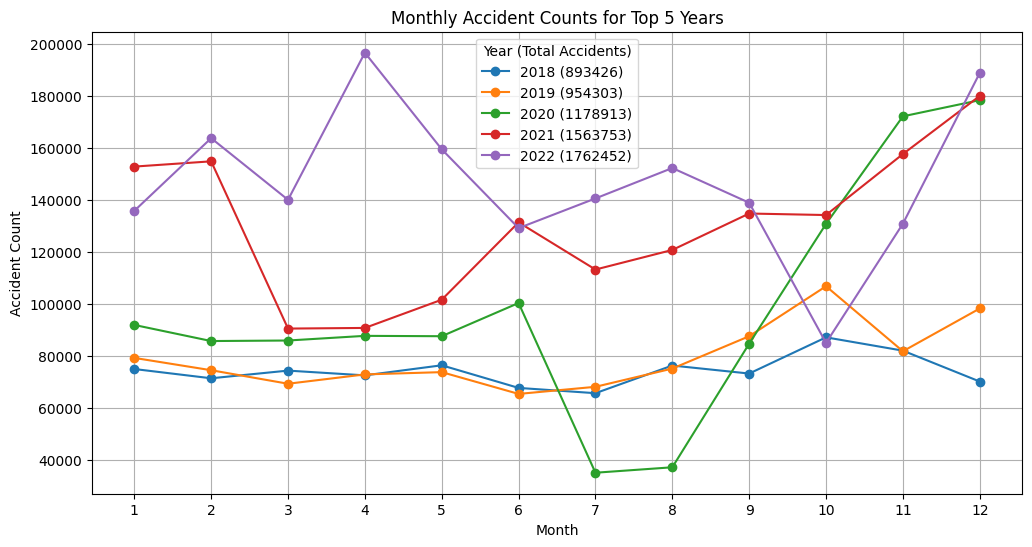

In [ ]:


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for year in sorted(top_years_list):
    # Kuukausidata
    data = monthly_pd[monthly_pd["Year"] == year]

    # Haetaan vuosikohtainen kokonaismäärä legendaa varten
    total = int(top_years_pd[top_years_pd["Year"] == year]["accident_count"].iloc[0])

    # Piirretään viiva
    plt.plot(
        data["Month"],
        data["accident_count"],
        marker="o",
        label=f"{year} ({total})"
    )

plt.title("Monthly Accident Counts for Top 5 Years")
plt.xlabel("Month")
plt.ylabel("Accident Count")
plt.xticks(range(1, 13))  # tammikuu → joulukuu
plt.legend(title="Year (Total Accidents)")
plt.grid(True)
plt.show()


Etsitään vuoden 2019 aineistosta vakavuuden 3,4 onnettomuudet sekä kaupungit, missä ne tapahtuivat. 
Poistetaan mahdolliset duplikaatit, mikäli tällaisia aineistossa on. Duplikaatin ajatellaan olevan kyseessä, jos eri ID, mutta sama Start_Lat, sama Start_Lng js Start_Time 120 sekunnin sisällä. 

Identify all accidents with severity levels 3 and 4 in the 2019 dataset, along with the cities where they occurred.
Remove any potential duplicates if they exist in the data.
A duplicate is defined as a case where the ID is different, but the Start_Lat, Start_Lng, and Start_Time occur within 120 seconds of each other.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql.functions import unix_timestamp
from pyspark.sql.window import Window
from pyspark.sql.functions import lag


# Aikaleimat sekunteina ja aikaeron laskeminen edelliseen tapahtumaan
df2 = df.withColumn("ts", unix_timestamp("Start_Time"))

w = Window.partitionBy("Start_Lat", "Start_Lng").orderBy("ts")

df_with_prev = (
    df2
    .withColumn("prev_ts", lag("ts").over(w))
    .withColumn("time_diff_sec", col("ts") - col("prev_ts"))
)

# Mahdollisten duplikaatit suodatus ja näyttö
possible_duplicates = df_with_prev.filter(
    (col("time_diff_sec") >= 0) & (col("time_diff_sec") <= 120)
)

print("Mahdolliset duplikaatit:")
possible_duplicates.select(
    "ID",
    "Start_Time",
    "prev_ts",
    "time_diff_sec",
    "Start_Lat",
    "Start_Lng",
    "City"

).show(10, truncate=False)


# Poistetaan duplikaatit ja näytetään puhdistettu data
df_clean = df.join(possible_duplicates.select("ID"), on="ID", how="left_anti")

print("Puhdistettu data (ei duplikaatteja):")
df_clean.show(10, truncate=False)



Mahdolliset duplikaatit:
+---------+-------------------+----------+-------------+-----------+------------+------------+
|ID       |Start_Time         |prev_ts   |time_diff_sec|Start_Lat  |Start_Lng   |City        |
+---------+-------------------+----------+-------------+-----------+------------+------------+
|A-4738319|2022-04-16 00:50:00|1650059400|0            |24.928076  |-80.623798  |Islamorada  |
|A-6870527|2020-12-11 17:11:00|1607699460|0            |25.010744  |-80.515575  |Tavernier   |
|A-5197982|2022-07-16 16:25:00|1657977900|0            |25.197402  |-80.416375  |Key Largo   |
|A-6908323|2020-12-22 13:22:30|1608636150|0            |25.439905  |-80.474961  |Homestead   |
|A-6883295|2020-09-20 23:10:33|1600632633|0            |25.447736  |-80.485336  |Homestead   |
|A-6858144|2020-11-23 03:39:30|1606095570|0            |25.447802  |-80.491357  |Homestead   |
|A-3613060|2017-05-08 14:47:47|1494244067|0            |25.44785   |-80.48533   |Florida City|
|A-4206379|2023-01-14 16:

In [42]:
print("Rivimäärä ennen puhdistusta:", df.count())
print("Rivimäärä puhdistuksen jälkeen:", df_clean.count())




Rivimäärä ennen puhdistusta: 7728394
Rivimäärä puhdistuksen jälkeen: 7162203


Eniten onnettomuuksia tapahtui vuonna 2019. Lasketaan onnettomuuksien määrä kuukausitasolla ja näytetään top 5 kaupunkia vakavien (severity 3, 4) osalta

The highest number of accidents occurred in 2019.
Calculate the number of accidents on a monthly basis and display the top 5 cities with the most accidents.

In [ ]:
import pyspark.sql.functions as F

# Suodatus vuoden 2019 vakavista onnettomuuksista
severe_2019 = (
    df_clean
    .filter(F.col("Severity").isin(3, 4))
    .filter(F.year("Start_Time") == 2019)
)

# Lasketaan näistä top5
city_totals_2019 = (
    severe_2019
    .groupBy("City")
    .count()
    .orderBy(F.col("count").desc())
)

top5_cities = city_totals_2019.limit(5).select("City")

# Kuukausikohtaisten määrien laskenta
monthly_city_counts_top5 = (
    severe_2019
    .withColumn("Month", F.month("Start_Time"))
    .join(top5_cities, on="City", how="inner")
    .groupBy("City", "Month")
    .count()
    .orderBy("City", "Month")
)

monthly_pd = monthly_city_counts_top5.toPandas()


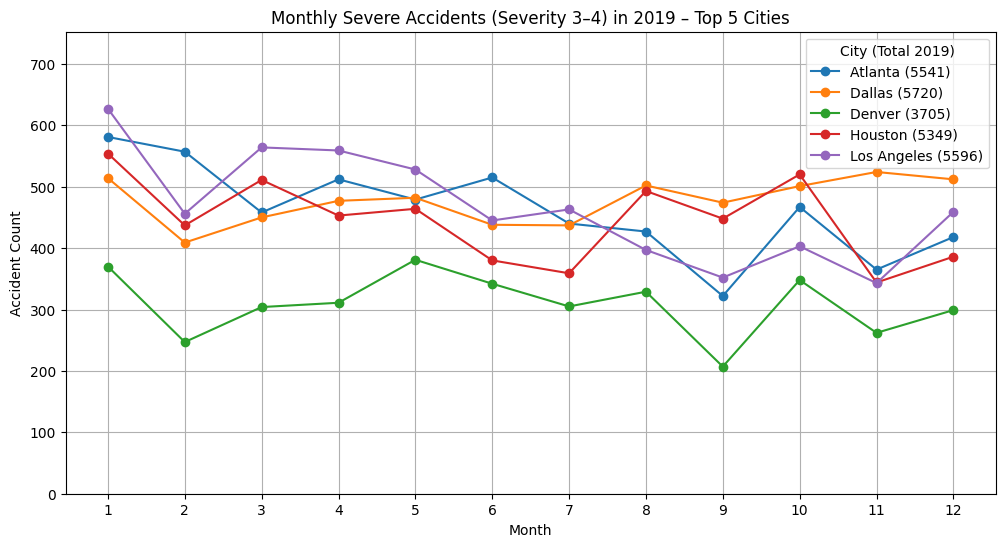

In [ ]:
# visualisonti

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Haetaan vuosittaiset kokonaismäärät legendaa varten
city_totals_pd = city_totals_2019.toPandas()   # sisältää City + count

for city in monthly_pd["City"].unique():
    data = monthly_pd[monthly_pd["City"] == city]

    # Haetaan kaupungin vuosittainen kokonaismäärä
    total = int(city_totals_pd[city_totals_pd["City"] == city]["count"].iloc[0])

    # Piirretään viiva
    plt.plot(
        data["Month"],
        data["count"],
        marker="o",
        label=f"{city} ({total})"
    )

plt.title("Monthly Severe Accidents (Severity 3–4) in 2019 – Top 5 Cities")
plt.xlabel("Month")
plt.ylabel("Accident Count")

# Kuukaudet 1–12
plt.xticks(range(1, 13))

# Y-akselille lisää tilaa (20 % ylimääräistä)
ymax = monthly_pd["count"].max()
plt.ylim(0, ymax * 1.2)

# Legenda oikeaan yläkulmaan
plt.legend(title="City (Total 2019)", loc="upper right")

plt.grid(True)
plt.show()


MongoDB 
Mongon dokumenttipohjan luominen
Creating a MongoDB-ready document schema

In [45]:
time_df = create_time_df(df_clean)
geo_df = create_geo_df(df_clean)
time_enriched = (
    time_df
    .join(df_clean.select("ID", "Severity", "City"), on="ID", how="left")
    .join(geo_df.select("ID", "Start_Lat", "Start_Lng"), on="ID", how="left")
)

time_enriched.show(5)



time_df created.

geo_df created.
+---------+-------------------+-------------------+-------------------+---------+-----------+-----+----------+---------------------+--------+----------+------------------+----------+
|       ID|         Start_Time|           End_Time|  Weather_Timestamp|time_hhmm|day_of_week|month|is_weekend|weather_delay_minutes|Severity|      City|         Start_Lat| Start_Lng|
+---------+-------------------+-------------------+-------------------+---------+-----------+-----+----------+---------------------+--------+----------+------------------+----------+
|A-1000044|2021-06-17 18:32:29|2021-06-17 19:35:06|2021-06-17 18:56:00|    18:32|        Thu|  Jun|         N|                -23.5|       3|York Haven|40.131401000000004|-76.796501|
|A-1000088|2021-06-17 08:15:20|2021-06-17 08:59:27|2021-06-17 07:53:00|    08:15|        Thu|  Jun|         N|                 22.3|       3|Cincinnati|         39.211849|  -84.4617|
|A-1000100|2021-06-17 13:42:49|2021-06-17 14:59:00

In [46]:

from pyspark.sql import SparkSession 
from pymongo import MongoClient
import pandas as pd
import time

client = MongoClient("mongodb://localhost:27017/")
db = client["US-Accidents"]
collection = db["accidents"]

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("MongoDBIntegration")
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:3.0.1")
    .config("spark.mongodb.output.uri", "mongodb://localhost:27017/Us-Accidents.accidents_clean")
    .getOrCreate()
)


                     

In [47]:
time_enriched.write.format("mongo") \
    .mode("overwrite") \
    .option("database", "traffic") \
    .option("collection", "accidents_clean") \
    .save()


Py4JJavaError: An error occurred while calling o903.save.
: org.apache.spark.SparkClassNotFoundException: [DATA_SOURCE_NOT_FOUND] Failed to find the data source: mongo. Please find packages at `https://spark.apache.org/third-party-projects.html`.
	at org.apache.spark.sql.errors.QueryExecutionErrors$.dataSourceNotFoundError(QueryExecutionErrors.scala:725)
	at org.apache.spark.sql.execution.datasources.DataSource$.lookupDataSource(DataSource.scala:647)
	at org.apache.spark.sql.execution.datasources.DataSource$.lookupDataSourceV2(DataSource.scala:697)
	at org.apache.spark.sql.DataFrameWriter.lookupV2Provider(DataFrameWriter.scala:873)
	at org.apache.spark.sql.DataFrameWriter.saveInternal(DataFrameWriter.scala:260)
	at org.apache.spark.sql.DataFrameWriter.save(DataFrameWriter.scala:251)
	at java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)
	at java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke(NativeMethodAccessorImpl.java:77)
	at java.base